In [45]:
import pandas as pd 
import seaborn as sns

In [8]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Wine .csv")
df.columns 

Index(['Unnamed: 0', 'Class Label ', 'Alcohol', 'Malic Acid ', '1', '1.1',
       '1.2', '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '1.10'],
      dtype='str')

In [9]:
df.columns = df.columns.str.strip()
df = df[["Class Label", "Alcohol", "Malic Acid"]]

In [10]:
df

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59
...,...,...,...
173,3,13.71,5.65
174,3,13.40,3.91
175,3,13.27,4.28
176,3,13.17,2.59


<Axes: xlabel='Malic Acid', ylabel='Density'>

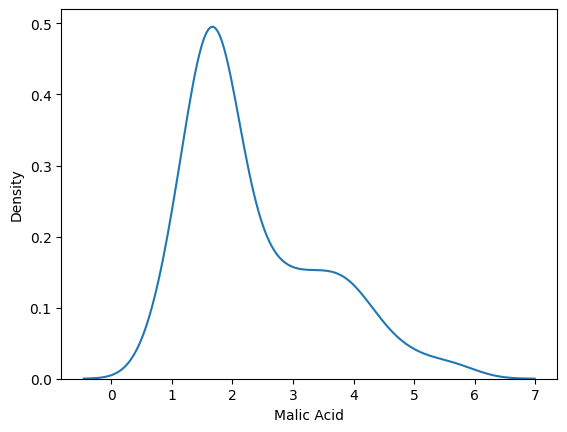

In [12]:
sns.kdeplot(df["Malic Acid"])

In [13]:
X = df[["Alcohol" , "Malic Acid"]]
y = df ["Class Label"]

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
MM = MinMaxScaler()

In [20]:
MM.fit(X_train)
X_trained = MM.transform(X_train)
X_tested = MM.transform(X_test)

In [28]:
X_trained = pd.DataFrame(X_trained , columns = X_train.columns)    # when we scale the sklearn convert our data into numpy array so we just change ot into data frame again
X_tested = pd.DataFrame(X_tested , columns  = X_test.columns)

In [31]:
round(X_trained.describe(),1)     # see min gets to 0 and max becomes 1 

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

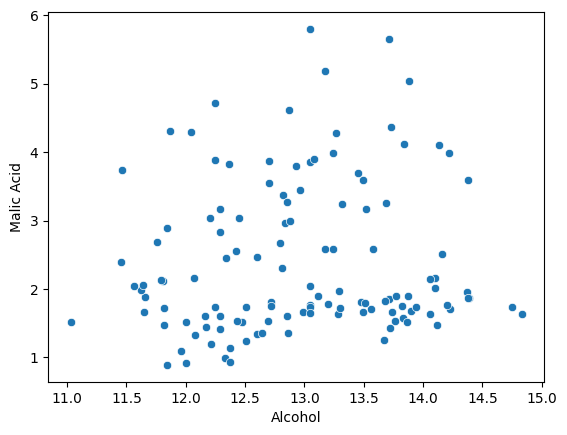

In [42]:
sns.scatterplot(data = X_train, x = "Alcohol" , y = "Malic Acid")   # before scalling

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

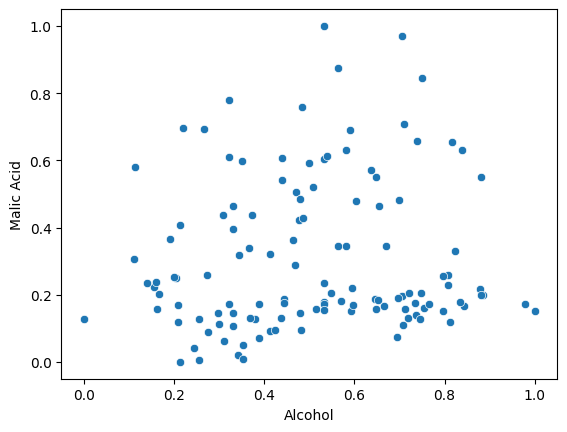

In [43]:
sns.scatterplot(data = X_trained , x = "Alcohol" , y = "Malic Acid")  # after scalling 

# Categorical Encoding 

In [52]:
import numpy as np

np.random.seed(42)            # by this you get a fix data as randint changes the data every time you run the code 

data = {
    'age': np.random.randint(18, 60, 20),              # min , max ,how many values to generate 
    'gender': np.random.choice(['Male', 'Female'], 20),
    'review': np.random.choice(['Good', 'Poor', 'Average'], 20),
    'education': np.random.choice(['School', 'UG', 'PG'], 20),
    'purchased': np.random.choice(['Yes', 'No'], 20)
}

df = pd.DataFrame(data)
df

,age,gender,review,education,purchased
0,56,Female,Average,School,No
1,46,Female,Poor,UG,No
2,32,Female,Poor,School,No
3,25,Male,Average,UG,No
4,38,Male,Poor,PG,No
5,56,Female,Average,PG,No
6,36,Female,Average,School,No
7,40,Female,Good,PG,No
8,28,Male,Average,PG,Yes
9,28,Female,Good,UG,No


In [57]:
df1 = df.iloc[:,2:]
df1.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Poor,School,No
3,Average,UG,No
4,Poor,PG,No


In [58]:
from sklearn.model_selection import train_test_split

In [61]:
X_train , X_test , y_train , y_test = train_test_split(df1.iloc[:,0:2] , df1.iloc[:,-1] , test_size = 0.3 , random_state = 42)

In [63]:
X_train.head()

,review,education
11,Average,UG
3,Average,UG
18,Poor,School
16,Good,UG
13,Good,UG


In [65]:
from sklearn.preprocessing import OrdinalEncoder 

In [69]:
OE = OrdinalEncoder(categories = [["Poor" , "Average" , "Good"], ["School" , "UG", "PG"]]) # defining order sab se bara number good ko mile gha chota number poor ko

In [70]:
OE.fit(X_train)
X_trained = OE.transform(X_train)
X_tested = OE.transform(X_test)

In [74]:
print(X_train.head())
print(X_trained)

     review education
11  Average        UG
3   Average        UG
18     Poor    School
16     Good        UG
13     Good        UG
[[1. 1.]
 [1. 1.]
 [0. 0.]
 [2. 1.]
 [2. 1.]
 [0. 0.]
 [2. 1.]
 [0. 2.]
 [0. 2.]
 [2. 1.]
 [2. 2.]
 [1. 0.]
 [1. 1.]
 [1. 0.]]


In [75]:
from sklearn.preprocessing import LabelEncoder

In [76]:
LE  = LabelEncoder()

In [77]:
LE.fit(y_train)

LabelEncoder()

In [78]:
y_train = LE.transform(y_train)
y_test  = LE.transform(y_test)

In [79]:
y_train

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [81]:
LE.classes_

array(['No', 'Yes'], dtype=object)

### One Hot Encoding 

In [89]:
df =pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Car Data.csv")
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


In [91]:
df["fuel"].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

## Using Pandas for one-hot encoding

In [102]:
pd.get_dummies(df , columns = ["fuel", "owner"], dtype = int)    # we use single [] because get_dummies work with sireies 

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


## K-1 Encoding 
##### Use to remove dummy varriable trap

In [95]:
pd.get_dummies(df, columns = ["fuel" , "owner"] , dtype =int , drop_first = True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,1,0,0,0,0,0,0
1,Skoda,120000,370000,1,0,0,0,1,0,0
2,Honda,140000,158000,0,0,1,0,0,0,1
3,Hyundai,127000,225000,1,0,0,0,0,0,0
4,Maruti,120000,130000,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,1,0,0,0,0
8124,Hyundai,119000,135000,1,0,0,1,0,0,0
8125,Maruti,120000,382000,1,0,0,0,0,0,0
8126,Tata,25000,290000,1,0,0,0,0,0,0


In [96]:
X_train , X_test , y_train , y_test = train_test_split(df.iloc[:,0:4], df.iloc[:,-1], test_size = 0.3 , random_state = 42)

In [99]:
from sklearn.preprocessing import OneHotEncoder

In [117]:
ohe = OneHotEncoder(drop = "first" , sparse_output = False , dtype = np.int32)

##### For machine learning projects we dont use pandas dummies we use sklearn OHE, beacue get dummies dont remeber which column category has which number

In [119]:
X_trained = ohe.fit_transform(X_train[["fuel" , "owner"]])   # we use double [] beacuse OHE needs data frame 

In [120]:
X_tested = ohe.transform(X_test[["fuel", "owner"]])

In [121]:
# now joining
np.hstack((X_train[["brand", "km_driven"]].values,X_trained))

array([['Maruti', 120000, 0, ..., 0, 0, 1],
       ['Toyota', 100000, 1, ..., 0, 0, 0],
       ['BMW', 39000, 1, ..., 0, 0, 0],
       ...,
       ['Hyundai', 35000, 0, ..., 0, 0, 0],
       ['Maruti', 27000, 1, ..., 0, 0, 0],
       ['Maruti', 70000, 0, ..., 1, 0, 0]], shape=(5689, 9), dtype=object)

### Now we have multiple brands in brand columns so we will set threeshold so which brands have less than 100 cars will go to others column

In [123]:
counts = df["brand"].value_counts()

In [124]:
threeshold = 100

In [127]:
repl = counts[counts <= threeshold].index

In [130]:
repl

Index(['Nissan', 'Jaguar', 'Volvo', 'Datsun', 'Mercedes-Benz', 'Fiat', 'Audi',
       'Lexus', 'Jeep', 'Mitsubishi', 'Land', 'Force', 'Isuzu', 'Kia',
       'Ambassador', 'MG', 'Daewoo', 'Ashok', 'Opel', 'Peugeot'],
      dtype='str', name='brand')

In [132]:
df[df["brand"].isin(repl)]

,brand,km_driven,fuel,owner,selling_price
31,Fiat,50000,Petrol,Second Owner,70000
38,Datsun,42000,Petrol,First Owner,150000
41,Jeep,5000,Petrol,First Owner,2100000
49,Mercedes-Benz,27800,Diesel,Second Owner,1450000
51,Mitsubishi,151000,Diesel,First Owner,1090000
...,...,...,...,...,...
8072,Nissan,82000,Diesel,Second Owner,450000
8090,Nissan,170000,Diesel,First Owner,509999
8091,Fiat,40000,Petrol,Second Owner,125000
8101,Fiat,70000,Diesel,First Owner,450000


In [140]:
pp = pd.get_dummies(df["brand"].replace(repl , "Uncommon"), dtype = int)